Compare different CV with deepLDA CV

## Setup

In [1]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import plumed
import math

In [2]:
import torch
from mlcolvar.utils.io import load_dataframe


In [3]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
TEST_NUM_STEPS   = 10_000     # for testing  
#NUM_STEPS   = 500_000    # productions
NUM_STEPS   = 10_000_000    # 20ns
STRIDE      = 10
#STRIDE      = 100

num_steps   = NUM_STEPS
test_num_steps = TEST_NUM_STEPS

os.chdir(BASE_DIR)

In [4]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [5]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

### biased simulation using $\phi$

In [6]:
# CREATE FOLDER AND COPY INPUTS
folder_phi = DATA_DIR / "2_biased-phi/"
Path(folder_phi).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_phi)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_phi)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [ ]:
# WRITE PLUMED INPUT FILE
with open(folder_phi / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in phi
metad: METAD ARG=phi ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=phi,psi
ENDPLUMED
""")

In [ ]:
clean(folder_phi) # note: this deletes all previous results in folder!

In [ ]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder_phi)

In [ ]:
# print command to run in terminal (for longer run)

print(f"cd {folder_phi}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

/tmp/ipykernel_108601/3423995857.py:2: UserWarning: cannot load PLUMED instance, conversions will not be available
  data=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++


Text(0, 0.5, 'phi [rad]')

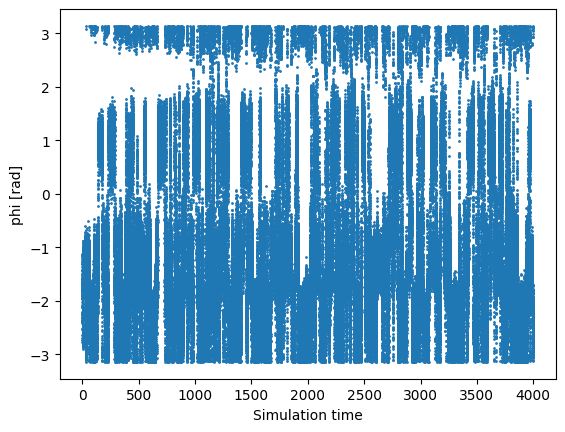

In [7]:
# visualize CV file
data=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
# plot phi during simulation (first 200k points)
plt.plot(data["time"][:200000],data["phi"][:200000],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'phi [rad]')

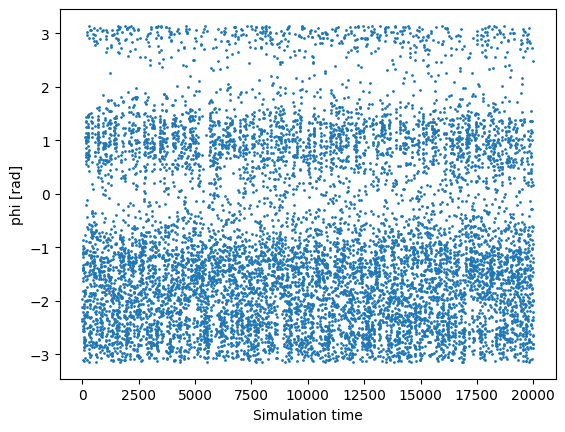

In [8]:
plt.plot(data["time"][::100],data["phi"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

/tmp/ipykernel_108601/550064424.py:2: UserWarning: cannot load PLUMED instance, conversions will not be available
  data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++


Text(0, 0.5, 'height [kj/mol]')

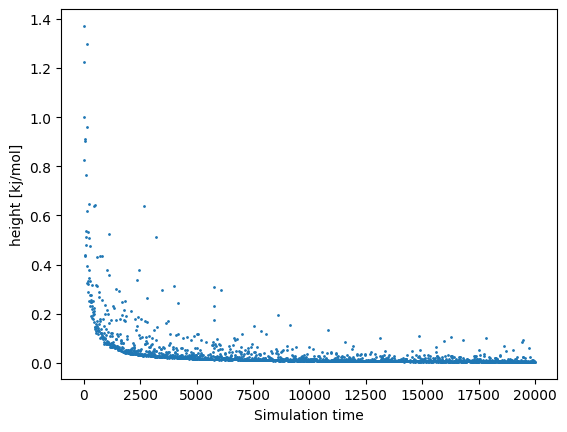

In [9]:
# visualize CV file
data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
# plot phi during simulation (first 200k points)
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("height [kj/mol]")

In [10]:
data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
data_phi.head()

/tmp/ipykernel_108601/3489747285.py:1: UserWarning: cannot load PLUMED instance, conversions will not be available
  data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++


,time,phi,psi
0,0.00,-2.36867,2.64432
1,0.02,-2.38391,2.56521
2,0.04,-2.22548,2.51866
3,0.06,-2.29910,2.43971
4,0.08,-2.21197,2.34191


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
/tmp/ipykernel_108601/4216193110.py:4: UserWarning: cannot load PLUMED instance, conversions will not be available
  dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUME

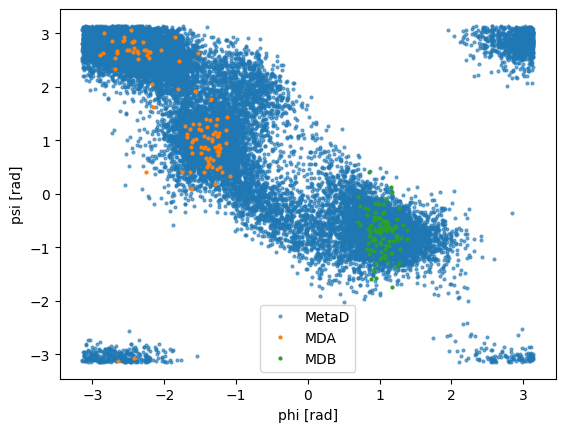

In [11]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
dataB = plumed.read_as_pandas(str(folderB / "COLVAR"))
data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))

# plot phi vs psi
plt.plot(data_phi["phi"][::50],data_phi["psi"][::50],'o', alpha=0.6, ms=2, label="MetaD")
plt.plot(dataA["phi"][::50],dataA["psi"][::50],'o', ms=2, label="MDA")
plt.plot(dataB["phi"][::50],dataB["psi"][::50],'o', ms=2, label="MDB")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("psi [rad]")
plt.legend()

In [ ]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_phi)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
/tmp/ipykernel_108601/295907518.py:5: UserWarning: cannot load PLUMED instance, conversions will not be available
  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ Loading the PLUMED kernel runtime +++

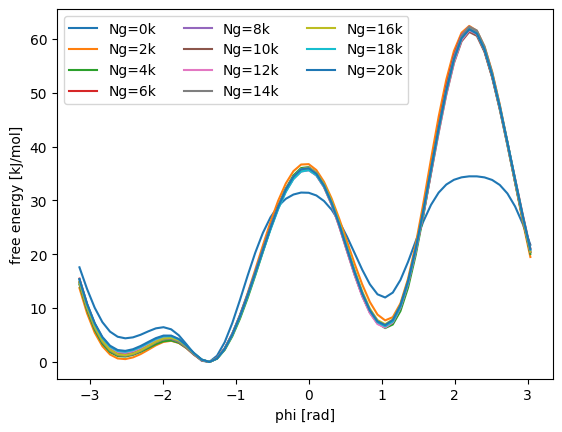

In [12]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
 data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 # plot fes
 plt.plot(data["phi"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

/tmp/ipykernel_108601/1990945728.py:7: UserWarning: cannot load PLUMED instance, conversions will not be available
  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ Loading the PLUMED kernel runtime ++

Text(0, 0.5, 'DeltaF [kJ/mol]')

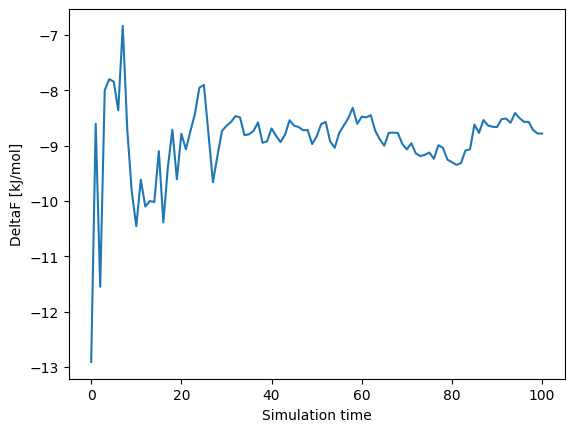

In [13]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
 data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["phi"])):
     phi = data["phi"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-3<=phi<=-1):   F0 += p
     if(0.5<=phi<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

### reweighting

In [48]:
# CREATE FOLDER AND COPY INPUTS
folder_rw = DATA_DIR / "2_biased-phi-rw/"
Path(folder_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [23]:
# WRITE PLUMED INPUT FILE
with open(folder_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in phi
metad: METAD ARG=phi ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_phi}/HILLS GRID_MIN=-pi GRID_MAX=pi
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")

In [24]:
# analyze with PLUMED driver
execute(f"plumed driver --mf_xtc {folder_phi}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339", folder=folder_rw)

Completed: plumed driver --mf_xtc /home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339


In [ ]:
# now compare free energy from metadynamics bias and reweighting
#data_b=plumed.read_as_pandas(str(folder_phi / "fes_100.dat"))
#data_r=plumed.read_as_pandas(str(folder_rw / "ffphi.dat"))

In [15]:
# now compare free energy from metadynamics bias and reweighting
data_b=load_dataframe(f"{folder_phi}/fes_100.dat")
data_r=load_dataframe(f"{folder_rw}/ffphi.dat")               

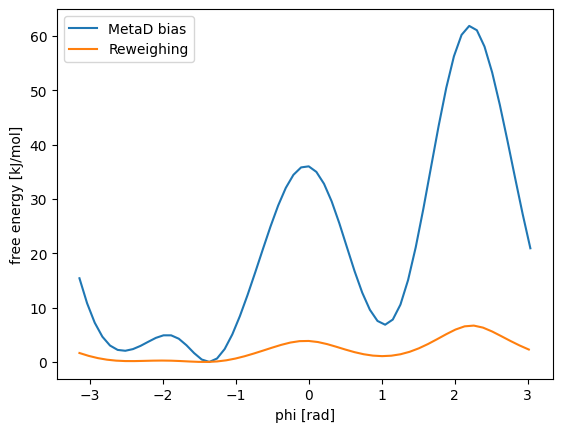

In [16]:


# plot free energies
plt.plot(data_b["phi"],data_b["file.free"],label="MetaD bias")
plt.plot(data_r["phi"],data_r["ffphi"]-min(data_r["ffphi"]),label="Reweighing")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

In [21]:
colvar =plumed.read_as_pandas(str(folder_rw /"COLVAR_REWEIGHT"))

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
/tmp/ipykernel_108601/3831475993.py:1: UserWarning: cannot load PLUMED instance, conversions will not be available
  colvar =plumed.read_as_pandas(str(folder_rw /"COLVAR_REWEIGHT"))
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++


In [22]:
colvar.head()

,time,phi,psi,metad.bias
0,0.0,-2.368269,2.643942,99.737540
1,1.0,-1.818813,2.266430,97.978734
2,2.0,-2.345259,2.601996,99.620770
3,3.0,-1.273902,0.118411,101.590225
4,4.0,-1.963553,2.974954,97.650720


(0.0, 50.0)

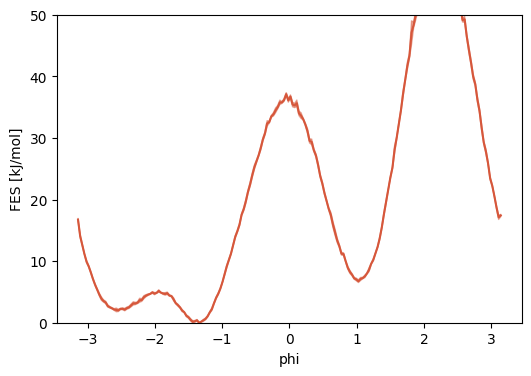

In [24]:
from mlcolvar.utils.fes import compute_fes
import mlcolvar.utils.plot

s = colvar['phi'].values

# compute weights
kbT = 2.5
w = np.exp(colvar['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('phi')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

In [25]:
def augment_periodic(cv,weights=None,bandwidth=0.1):
    """Add points across the periodic boundaries (-np.pi and np.pi)

    Parameters
    ----------
    cv : np.array
    weigths : np.array, optional
    bandwidth : float, optional
    """
    mask = (cv < -np.pi + 3*bandwidth)
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, index, cv[mask] + 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    mask = (cv > np.pi  - 5*bandwidth) & ( cv < np.pi )
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, np.argwhere(mask)[:,0], cv[mask] - 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    return cv, weights

phi = colvar['phi'].values
psi = colvar['psi'].values
w = np.exp(colvar['metad.bias'].values/kbT)

bandwidth = 0.05

phi, w_phi = augment_periodic(phi,w,bandwidth)
psi, w_psi = augment_periodic(psi,w,bandwidth)

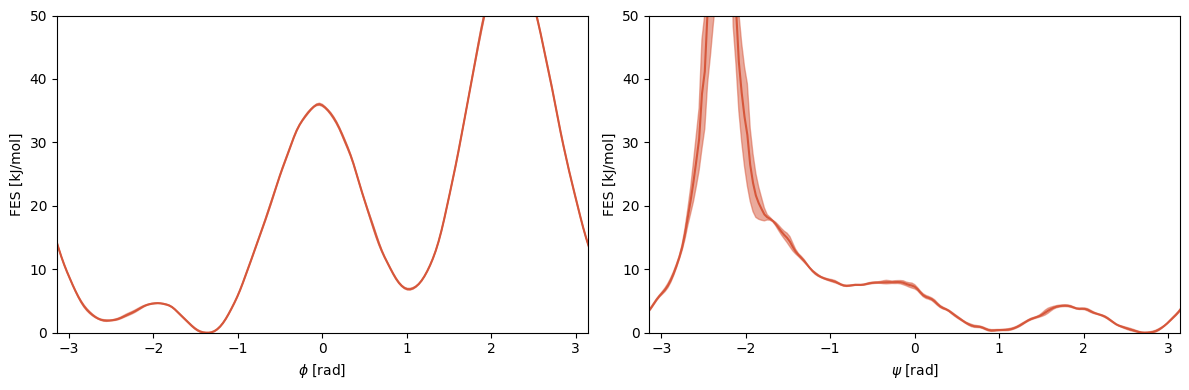

In [26]:
# compute weights
kbT = 2.5

#w = np.exp(colvar['metad.bias'].values/kbT)

#phi = colvar['phi'].values

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(psi, weights=w_psi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\psi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

plt.tight_layout()

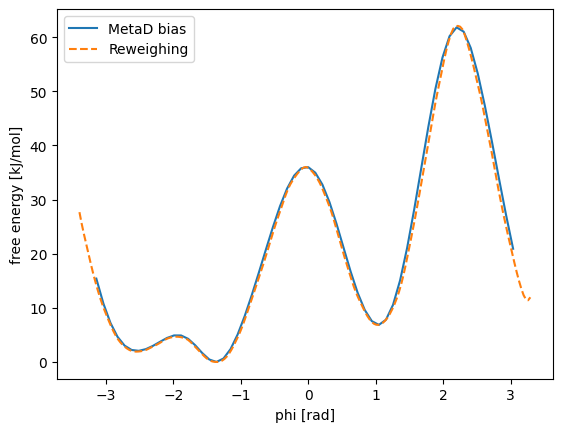

In [31]:
# now compare free energy from metadynamics bias and reweighting
data_b=load_dataframe(f"{folder_phi}/fes_100.dat")
data_r=load_dataframe(f"{folder_rw}/ffphi.dat")  

fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)

# plot free energies
plt.plot(data_b["phi"],data_b["file.free"],label="MetaD bias")
plt.plot(grid,fes-min(fes),label="Reweighing", linestyle='--')
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

### block analysis

In [63]:
print(folder_phi, folder_rw)

/home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi /home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi-rw


In [64]:
# CREATE FOLDER AND COPY INPUTS
folder_bl = DATA_DIR / "2_biased-phi-block/"
Path(folder_bl).mkdir(parents=True, exist_ok=True)

In [65]:
# --- MAPPATURA DEI PERCORSI ASSOLUTI PER L'ESERCIZIO ---
# Definiamo i percorsi assoluti come stringhe per usarli dentro Bash
script_block_fes = str(BASE_DIR  / "notebook/do_block_fes.py")

In [66]:
os.environ["DIR_3"] = str(folder_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 4 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $4}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($4-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

In [67]:
execute(bash_script, folder=folder_bl)

Completed: 
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 4 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $4}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($4-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks



/tmp/ipykernel_108601/2910098858.py:2: UserWarning: cannot load PLUMED instance, conversions will not be available
  data=plumed.read_as_pandas(str(f"{folder_bl}/err.blocks"))
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++
+++ This error is expected if you are trying to load a kernel <=2.4
+++ Trying /home/dani/plumed-2.10.0/src/lib/install/libplumed.so +++
+++ An error occurred. Message from dlopen(): /home/dani/plumed-2.10.0/src/lib/libplumedKernel.so: undefined symbol: _ZN2at4_ops5zeros4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEE +++


Text(0, 0.5, 'Average error on free-energy profile [kJ/mol]')

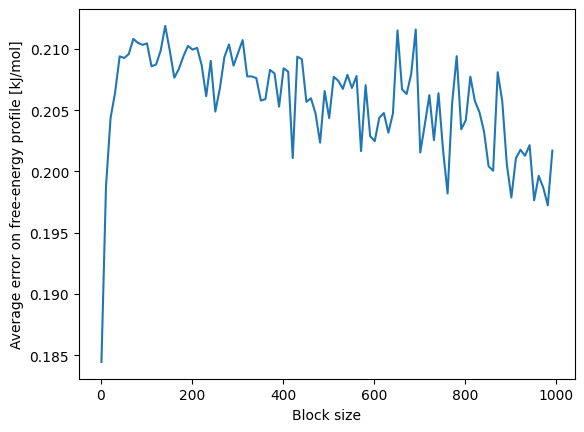

In [68]:
# import err.blocks file into pandas dataset
data=plumed.read_as_pandas(str(f"{folder_bl}/err.blocks"))
# plot error as a function of block size
plt.plot(data["bsize"],data["err"])
# x-y axis labels
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")